# **UTN Santa Fe - Ciencia de Datos**
## *TP N°1 - Parte 2: Preprocesamiento de datos y entrenamiento*

---
### **Librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### **Carga del conjunto de datos**
Realizamos la lectura del archivo `i40 (datos).csv` y visualizamos las primeras filas para comprobar que haya cargado correctamente.

In [2]:
# Leemos el archivo y visualizamos los primeros registros
df = pd.read_csv('i40 (datos).csv')
df.columns = df.columns.str.strip()
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [3]:
# Borramos los campos que no son necesarios para el modelo
df.drop('idx',axis=1, inplace=True)
df.drop('parent_device_id',axis=1, inplace=True)

df.head()

,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,L,303.80,313.30,1406,52.10,166,normal
1,L,302.30,311.20,1633,36.40,114,normal
2,M,302.27,311.47,1228,68.75,187,failure
3,L,302.35,311.93,1522,36.99,214,failure
4,L,296.70,307.90,1743,27.90,55,normal


---
### **Detección y tratamiento de datos faltantes**

Verificamos si existen datos faltantes:

In [4]:
valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

air_temp [K]    40
dtype: int64


Notamos que faltan 40 valores en la columna 'air_temp [K]' y los rellenamos con la mediana:

In [5]:
mediana = df['air_temp [K]'].median()
df['air_temp [K]'] = df['air_temp [K]'].fillna(mediana)

valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])

Series([], dtype: int64)


---
### **Detección y tratamiento de valores atípicos**
Visualizamos los valores atípicos de las variables numéricas mediante boxplots:

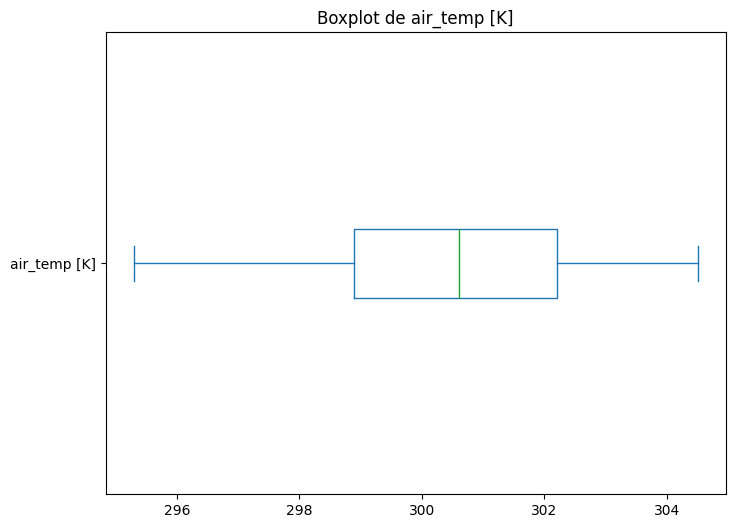

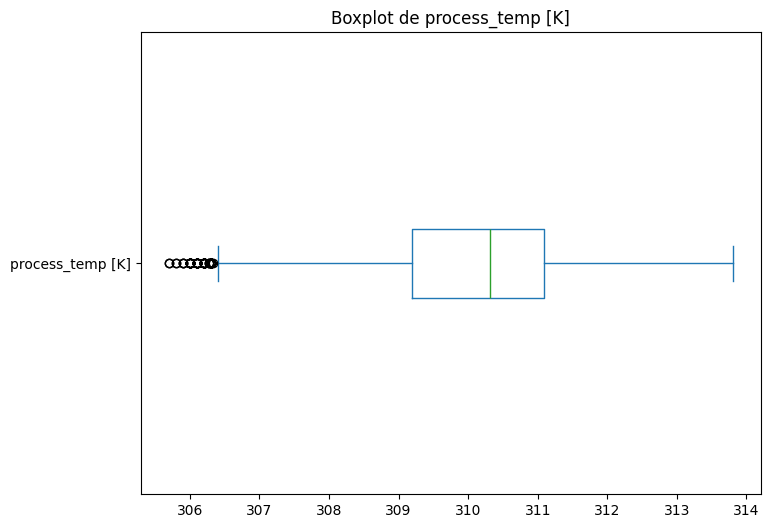

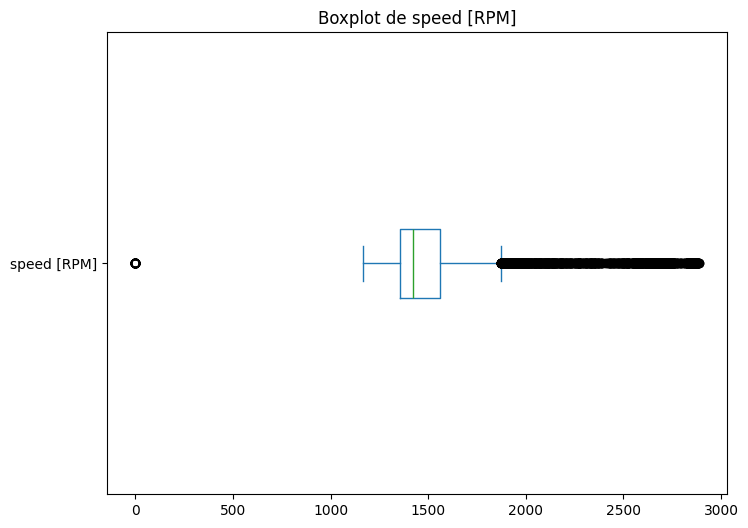

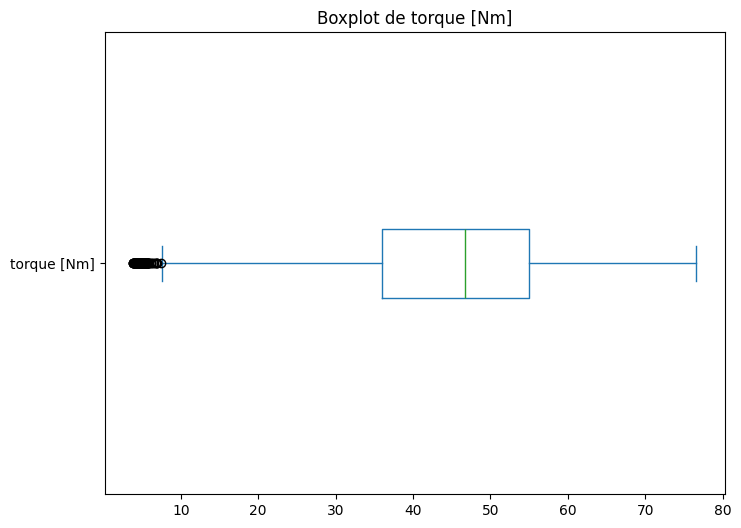

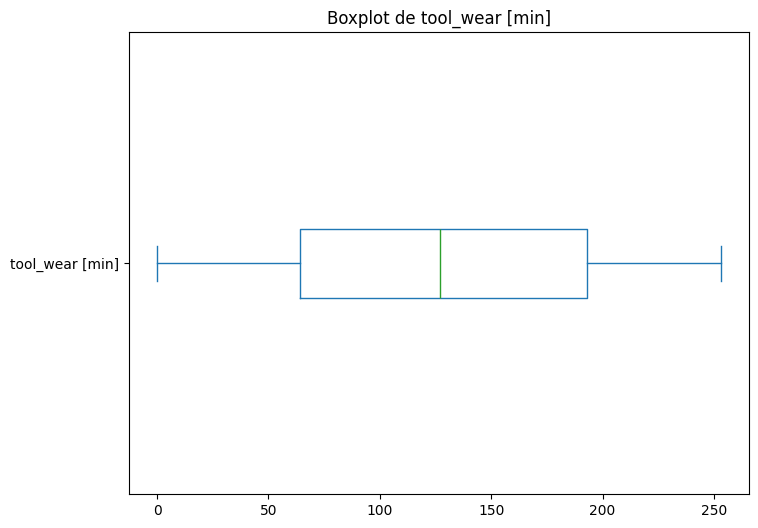

In [6]:
for columna in df.columns:
    if pd.api.types.is_numeric_dtype(df[columna]):
        plt.figure(figsize=(8, 6))
        df[columna].plot(kind='box', vert=False)
        plt.title(f"Boxplot de {columna}") 
        plt.show()

---
### **Tratamiento de valores atípicos**
Notamos que las columnas de 'process_temp [K]', 'speed [RPM]' y 'torque [Nm]' presentan valores atípicos. Optamos por reemplazar dichos valores por la mediana de los valores correctos:

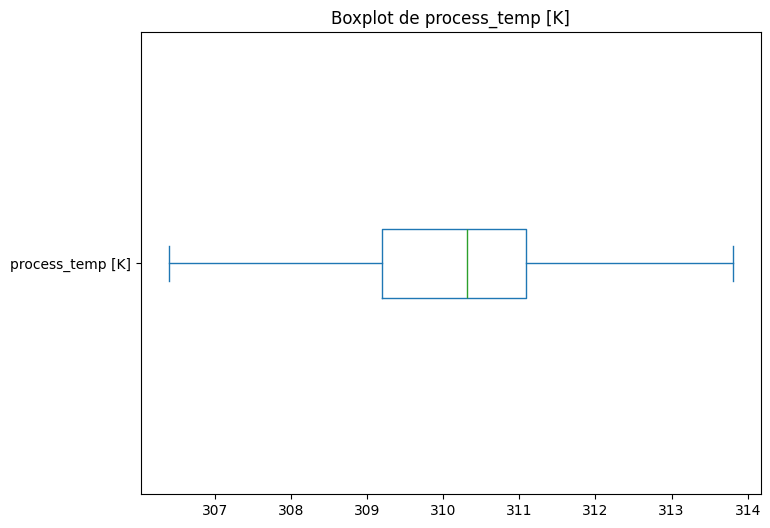

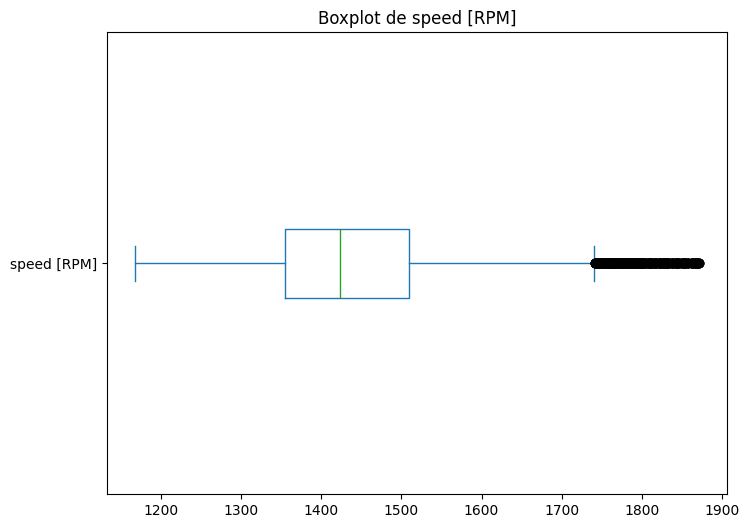

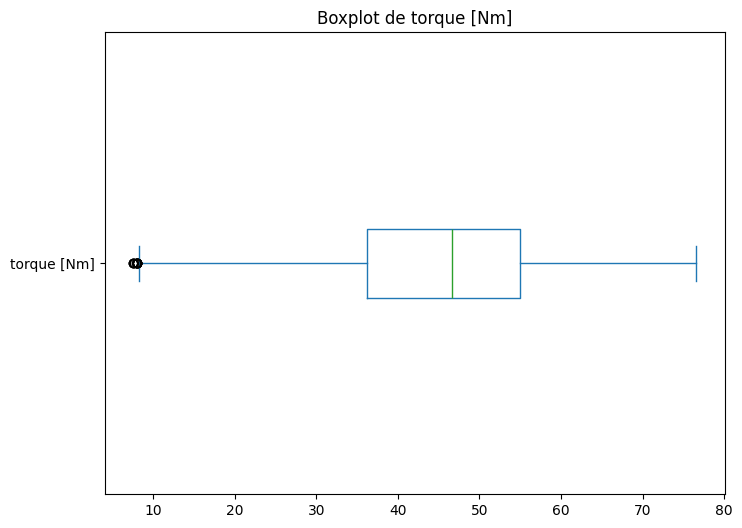

In [7]:
columnas_a_limpiar = ['process_temp [K]', 'speed [RPM]', 'torque [Nm]']

for col in columnas_a_limpiar:
    # Calculamos los límites del boxplot
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    # Calculamos la mediana
    mediana_col = df[col].median()
    
    # Si el valor está fuera de los límites, se reemplaza por la mediana
    df.loc[(df[col] < limite_inf) | (df[col] > limite_sup), col] = mediana_col

# Visualizamos nuevamente los boxplots
for columna in columnas_a_limpiar:
    if pd.api.types.is_numeric_dtype(df[columna]):
        plt.figure(figsize=(8, 6))
        df[columna].plot(kind='box', vert=False)
        plt.title(f"Boxplot de {columna}") 
        plt.show()

---
### **Correlación entre variables**
Calculamos las correlaciones de las columnas numéricas según un umbral de 0.9:

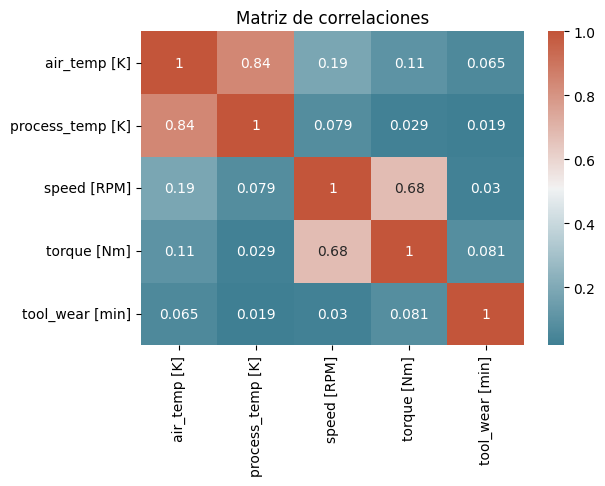

In [8]:
# Calculamos la matriz de correlación absoluta
corr = df.corr(numeric_only=True).abs()

# Calculamos un vector con las medias de cada columna
column_mean = corr.mean(axis=1)

# Visualizamos la matriz de correlación
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.tight_layout()
plt.title("Matriz de correlaciones")

# Calculo de las correlaciones de las columnas dado el umbral
umbral = .90
df_numbers = df[['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']]
for i in range(0,len(df_numbers.columns)):
    for j in  range(i,len(df_numbers.columns)):
        if i!=j:
            is_corr=np.abs(df_numbers[df_numbers.columns[i]].corr(df_numbers[df_numbers.columns[j]]))
            if is_corr > umbral:
                print("La variable ", df_numbers.columns[i] , " está altamente correlacionada con la variable ", df_numbers.columns[j])

---
### **Procesamiento de variables categóricas**
En este caso sólo tenemos variables categóricas nominales ('product_type' y 'target'). Para este tipo de variables categóricas se pretende evitar una ponderación que pueda sesgar el conjunto de datos, por lo que utilizaremos una codificación one-hot.

In [ ]:
df = pd.get_dummies(df, columns = ['product_type', 'target'], dtype=int)